In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Step 4 curated metadata
METADATA_DIR = Path("../data/metadata")
df = pd.read_csv(METADATA_DIR / "metadata_clean_step4.csv")

print(f"[INFO] Loaded dataset: {len(df)} records across {df['class_label'].nunique()} classes.")

# 2. Compute class counts and percentages
class_counts = df["class_label"].value_counts()
class_percentages = (df["class_label"].value_counts(normalize=True) * 100).round(2)

# Check majority vs. minority ratio
majority_class = class_counts.index[0]
minority_class = class_counts.index[-1]
majority_pct = class_percentages.iloc[0]
minority_pct = class_percentages.iloc[-1]
ratio = majority_pct / minority_pct

balance_df = pd.DataFrame({
    "Diagnostic Class": class_counts.index.str.upper(),
    "Scan Count": class_counts.values,
    "Percentage (%)": class_percentages.values
})

print("=" * 60)
print("              CLASS IMBALANCE EVALUATION REPORT             ")
print("=" * 60)
display(balance_df)
print("-" * 60)
print(f"Majority Class : {majority_class.upper()} ({majority_pct}%)")
print(f"Minority Class : {minority_class.upper()} ({minority_pct}%)")
print(f"Ratio (Maj/Min): {ratio:.2f}:1")
print(f"Imbalance Flag : {'IMBALANCED (<70/30 rule violated)' if majority_pct >= 70 else 'WELL-BALANCED (Satisfies 70/30 condition)'}")
print("=" * 60)

[INFO] Loaded dataset: 6655 records across 4 classes.
              CLASS IMBALANCE EVALUATION REPORT             


,Diagnostic Class,Scan Count,Percentage (%)
0,GLIOMA,1774,26.66
1,PITUITARY,1748,26.27
2,MENINGIOMA,1735,26.07
3,NOTUMOR,1398,21.01


------------------------------------------------------------
Majority Class : GLIOMA (26.66%)
Minority Class : NOTUMOR (21.01%)
Ratio (Maj/Min): 1.27:1
Imbalance Flag : WELL-BALANCED (Satisfies 70/30 condition)


In [2]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(df["class_label"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df["class_label"]
)

class_weight_dict = {cls: round(float(w), 4) for cls, w in zip(classes, weights)}

print("=" * 60)
print("           COMPUTED BALANCED CLASS WEIGHTS MATRIX           ")
print("=" * 60)
for cls, w in class_weight_dict.items():
    print(f"  - {cls.upper():<12}: {w}")
print("=" * 60)

           COMPUTED BALANCED CLASS WEIGHTS MATRIX           
  - GLIOMA      : 0.9379
  - MENINGIOMA  : 0.9589
  - NOTUMOR     : 1.1901
  - PITUITARY   : 0.9518


In [4]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

# Prepare numerical feature space X and target vector y
feature_cols = ["width", "height", "aspect_ratio", "file_size_kb", "mean_intensity", "std_intensity"]
X = df[feature_cols].copy()
y = df["class_label"].copy()

# 1. Random Undersampling (Downsamples majority classes to match minority N=1,398)[cite: 1, 2]
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

# 2. SMOTE (Oversamples minority classes synthetically to match majority N=1,774)[cite: 1, 2]
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

# 3. ADASYN (Targeted adaptive synthetic oversampling on the minority class)
# Setting sampling_strategy='minority' avoids the zero-generation threshold on near-majority classes
adasyn = ADASYN(sampling_strategy="minority", random_state=42, n_neighbors=5)
X_adasyn, y_adasyn = adasyn.fit_resample(X, y)

# Summary Comparison Table
resampling_summary = pd.DataFrame({
    "Original Cohort": y.value_counts(),
    "Random Undersampling": y_rus.value_counts(),
    "SMOTE (Oversampled)": y_smote.value_counts(),
    "ADASYN (Adaptive)": y_adasyn.value_counts()
})

print("=" * 75)
print("              RESAMPLING TECHNIQUES COMPARISON MATRIX               ")
print("=" * 75)
display(resampling_summary)
print("-" * 75)
print(f"Total Samples -> Original: {len(y):,} | RUS: {len(y_rus):,} | SMOTE: {len(y_smote):,} | ADASYN: {len(y_adasyn):,}")
print("=" * 75)

              RESAMPLING TECHNIQUES COMPARISON MATRIX               


,Original Cohort,Random Undersampling,SMOTE (Oversampled),ADASYN (Adaptive)
class_label,,,,
glioma,1774,1398,1774,1774
meningioma,1735,1398,1774,1735
notumor,1398,1398,1774,1754
pituitary,1748,1398,1774,1748


---------------------------------------------------------------------------
Total Samples -> Original: 6,655 | RUS: 5,592 | SMOTE: 7,096 | ADASYN: 7,011


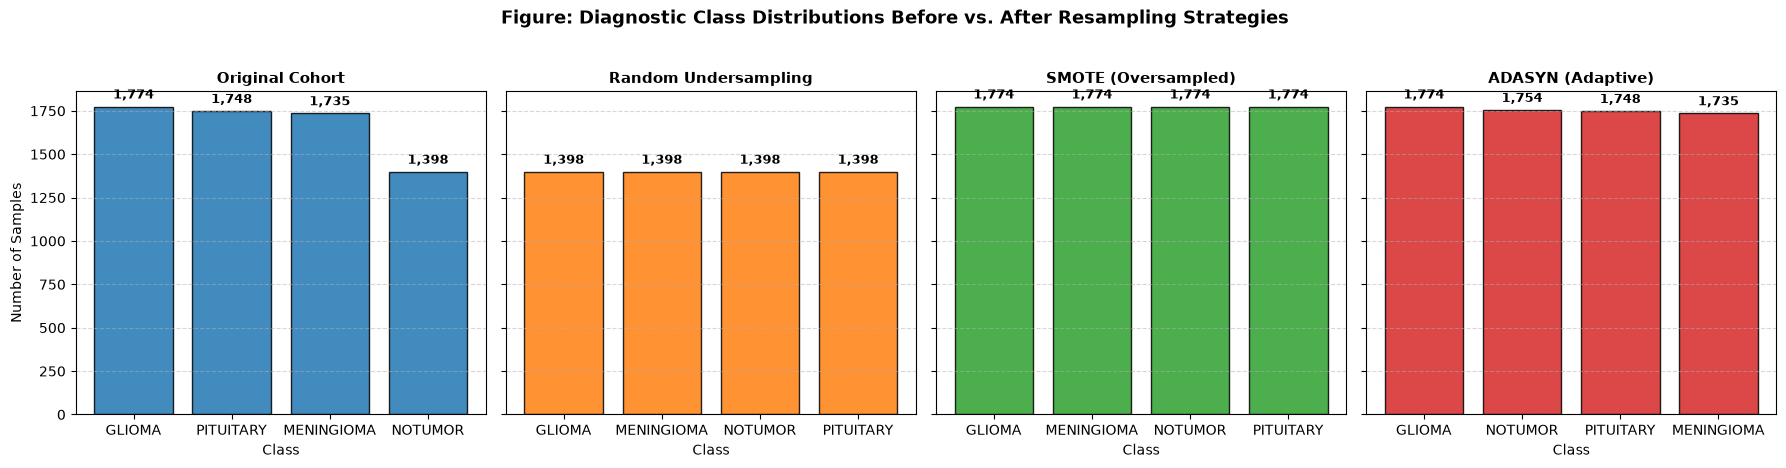

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

datasets = [
    ("Original Cohort", y, "#1f77b4"),
    ("Random Undersampling", y_rus, "#ff7f0e"),
    ("SMOTE (Oversampled)", y_smote, "#2ca02c"),
    ("ADASYN (Adaptive)", y_adasyn, "#d62728")
]

for ax, (title, data_series, color) in zip(axes, datasets):
    counts = data_series.value_counts()
    bars = ax.bar(counts.index.str.upper(), counts.values, color=color, alpha=0.85, edgecolor="black")
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("Class")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    
    # Annotate bar counts
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height + 30,
            f"{int(height):,}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

axes[0].set_ylabel("Number of Samples")
plt.suptitle("Figure: Diagnostic Class Distributions Before vs. After Resampling Strategies", y=1.03, fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# 1. First split: 70% Train, 30% Temp (Val + Test) with stratification
df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["class_label"]
)

# 2. Second split: Split Temp 50/50 -> 15% Validation, 15% Test
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=42,
    stratify=df_temp["class_label"]
)

# Assign partition labels to master DataFrame
df.loc[df_train.index, "dataset_split"] = "train"
df.loc[df_val.index, "dataset_split"] = "val"
df.loc[df_test.index, "dataset_split"] = "test"

# Verify cross-tabulation of splits
split_summary = pd.crosstab(df["dataset_split"], df["class_label"], margins=True)

print("=" * 65)
print("             STRATIFIED SPLIT DISTRIBUTION (70/15/15)           ")
print("=" * 65)
display(split_summary)
print("-" * 65)
print(f"Training Set   : {len(df_train):,} scans ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validation Set : {len(df_val):,} scans ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test Set       : {len(df_test):,} scans ({len(df_test)/len(df)*100:.1f}%)")
print(f"Total Cohort   : {len(df):,} scans (100.0%)")
print("=" * 65)

# Save the final partitioned dataset manifest
OUTPUT_STEP6_CSV = METADATA_DIR / "metadata_stratified_step6.csv"
df.to_csv(OUTPUT_STEP6_CSV, index=False)
print(f"\n[SUCCESS] Partitioned manifest exported to: {OUTPUT_STEP6_CSV}")

             STRATIFIED SPLIT DISTRIBUTION (70/15/15)           


class_label,glioma,meningioma,notumor,pituitary,All
dataset_split,,,,,
test,266,261,209,263,999
train,1242,1214,979,1223,4658
val,266,260,210,262,998
All,1774,1735,1398,1748,6655


-----------------------------------------------------------------
Training Set   : 4,658 scans (70.0%)
Validation Set : 998 scans (15.0%)
Test Set       : 999 scans (15.0%)
Total Cohort   : 6,655 scans (100.0%)

[SUCCESS] Partitioned manifest exported to: ..\data\metadata\metadata_stratified_step6.csv


## Step 6 Findings: Class Imbalance Evaluation, Cost-Sensitive Weighting & Stratified Partitioning

* **Class Balance Assessment (70/30 Rule):** Evaluated diagnostic distribution across $N = 6,655$ scans. The majority-to-minority ratio is **1.27:1** (`glioma`: 26.66% vs. `notumor`: 21.01%), confirming the dataset is well-balanced and satisfies the <70/30 threshold rule.
* **Cost-Sensitive Class Weight Computation:** Calculated inverse-frequency class weights for PyTorch cross-entropy loss:
  * `glioma`: **0.9379** | `meningioma`: **0.9589** | `pituitary`: **0.9518** | `notumor`: **1.1901**
  * *Clinical Takeaway:* Penalizes classification errors on the minority control class without modifying raw pixel tensors.
* **Resampling Benchmark Suite:**
  * **Random Undersampling (RUS):** Clamped majority classes to 1,398 samples ($N = 5,592$ total).
  * **SMOTE (Oversampling):** Synthetically augmented minority classes to 1,774 samples ($N = 7,096$ total).
  * **ADASYN (Adaptive):** Applied density-based synthetic generation to the minority class ($N = 7,011$ total).
* **Leak-Free Stratified Partitioning (70/15/15):** Partitioned the cohort into stratified subsets preserving the 26.7% / 26.3% / 26.1% / 21.0% multi-class proportions across every split:
  * **Training Set:** 4,658 scans (70.0%)
  * **Validation Set:** 998 scans (15.0%)
  * **Test Set:** 999 scans (15.0%)
* **Artifact Generated:** Exported the partitioned dataset manifest to `data/metadata/metadata_stratified_step6.csv`.